In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/recipedb-bio/BIO_Annotated_RecipeDB_data.csv


In [2]:
!pip install seqeval

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.6/43.6 kB 2.1 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Created wheel for seqeval: filename=seqeval-1.2.2-py3-none-any.whl size=16162 sha256=a1cd1d19bdaa055310da6bed1938286cded42fb15f6857bb84c5914df2a08882
  Stored in directory: /root/.cache/pip/wheels/bc/92/f0/243288f899c2eacdfa8c5f9aede4c71a9bad0ee26a01dc5ead
Successfully built seqeval


In [3]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from transformers import AutoTokenizer, AutoModelForTokenClassification
from torch.optim import AdamW 
from torch.utils.data import Dataset, DataLoader
import torch
from tqdm import tqdm
from seqeval.metrics import f1_score, precision_score, recall_score, classification_report
import matplotlib.pyplot as plt
import os

In [4]:
# Model and training parameters
MODEL_CHECKPOINT = 'microsoft/deberta-base' # You can swap this with 'roberta-base', 'bert-base-cased', etc.
MAX_LEN = 128
BATCH_SIZE = 16
EPOCHS = 15 # Feel free to increase this
LEARNING_RATE = 5e-5

In [5]:
# Setup device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cuda


In [6]:
# **MODIFICATION 1: Updated Label Dictionary as per your labels**
label_dict = {
    'O': 0,
    'B-NAME': 1, 'I-NAME': 2,
    'B-QUANTITY': 3, 'I-QUANTITY': 4,
    'B-UNIT': 5, 'I-UNIT': 6,
    'B-STATE': 7, 'I-STATE': 8,
    'B-TEMP': 9, 'I-TEMP': 10,
    'B-DF': 11, 'I-DF': 12,
}

In [7]:
label_dict_inv = {v: k for k, v in label_dict.items()}
num_labels = len(label_dict)
print(f"\nUsing Label Dictionary:\n{label_dict}")


Using Label Dictionary:
{'O': 0, 'B-NAME': 1, 'I-NAME': 2, 'B-QUANTITY': 3, 'I-QUANTITY': 4, 'B-UNIT': 5, 'I-UNIT': 6, 'B-STATE': 7, 'I-STATE': 8, 'B-TEMP': 9, 'I-TEMP': 10, 'B-DF': 11, 'I-DF': 12}


In [8]:
file_path = '/kaggle/input/recipedb-bio/BIO_Annotated_RecipeDB_data.csv'
print(f"\nAttempting to load data from: {file_path}")
data = pd.read_csv(file_path)
print(f"Successfully loaded data. Shape: {data.shape}")
# data.drop("Unnamed: 0", axis=1, inplace=True)


Attempting to load data from: /kaggle/input/recipedb-bio/BIO_Annotated_RecipeDB_data.csv
Successfully loaded data. Shape: (26444, 2)


In [9]:
data.head()

,Sentence,Labels
0,"2 tablespoons vegetable oil , divided",B-QUANTITY B-UNIT B-NAME I-NAME O B-STATE
1,2 tablespoons dried marjoram,B-QUANTITY B-UNIT B-DF B-NAME
2,"1 large red onion , 1/4-inch slices pulled int...",B-QUANTITY B-SIZE B-NAME I-NAME O O O O O O
3,"2 jalapeno peppers , seeded and minced",B-QUANTITY B-NAME I-NAME O B-STATE O B-STATE
4,1 tablespoon olive oil,B-QUANTITY B-UNIT B-NAME I-NAME


In [10]:
data.dropna(inplace=True)
data = data[data['Sentence'].astype(str).str.strip() != ''].reset_index(drop=True)

train_data, test_data = train_test_split(data, test_size=0.20, random_state=48)
print(f"Train set size: {len(train_data)}")
print(f"Test set size: {len(test_data)}")

Train set size: 21155
Test set size: 5289


In [11]:
# --- 3. Custom PyTorch Dataset ---
# (This class remains unchanged, it's designed to work with the loaded DataFrame)
class CocktailNERDataset(Dataset):
    def __init__(self, dataframe, tokenizer, label_dict, max_len):
        self.data = dataframe.reset_index(drop=True)
        self.tokenizer = tokenizer
        self.label_dict = label_dict
        self.max_len = max_len

    def __len__(self):
        return len(self.data)

    def __getitem__(self, index):
        row = self.data.iloc[index]
        sentence = str(row['Sentence']).strip()
        word_labels = str(row['Labels']).split()
        
        words = sentence.split()
        encoding = self.tokenizer(
            words,
            is_split_into_words=True,
            padding='max_length',
            truncation=True,
            max_length=self.max_len,
            return_tensors='pt'
        )

        aligned_labels = [-100] * self.max_len
        word_ids = encoding.word_ids()
        previous_word_idx = None
        for i, word_idx in enumerate(word_ids):
            if word_idx is None:
                continue
            if word_idx != previous_word_idx:
                if word_idx < len(word_labels): # Check to prevent index out of bounds
                    label = word_labels[word_idx]
                    aligned_labels[i] = self.label_dict.get(label, 0) # Default to 'O' if label not in dict
            previous_word_idx = word_idx

        return {
            'input_ids': encoding['input_ids'].flatten(),
            'attention_mask': encoding['attention_mask'].flatten(),
            'labels': torch.tensor(aligned_labels, dtype=torch.long)
        }


In [12]:
# --- 4. Model Initialization and Dataloaders ---
tokenizer = AutoTokenizer.from_pretrained(MODEL_CHECKPOINT, add_prefix_space=True)
model = AutoModelForTokenClassification.from_pretrained(MODEL_CHECKPOINT, num_labels=num_labels)
model.to(device)

train_dataset = CocktailNERDataset(train_data, tokenizer, label_dict, MAX_LEN)
test_dataset = CocktailNERDataset(test_data, tokenizer, label_dict, MAX_LEN)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)

optimizer = AdamW(model.parameters(), lr=LEARNING_RATE)

tokenizer_config.json:   0%|          | 0.00/52.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/474 [00:00<?, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

2025-11-14 05:07:40.542102: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1763096860.721746      19 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1763096860.775870      19 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered


pytorch_model.bin:   0%|          | 0.00/559M [00:00<?, ?B/s]

Some weights of DebertaForTokenClassification were not initialized from the model checkpoint at microsoft/deberta-base and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


In [13]:
# --- 5. Training and Evaluation Functions ---
# (These functions remain unchanged)
def train_epoch(model, data_loader, optimizer, device):
    model.train()
    total_loss = 0
    for batch in tqdm(data_loader, desc="Training"):
        optimizer.zero_grad()
        inputs = {key: val.to(device) for key, val in batch.items()}
        outputs = model(**inputs)
        loss = outputs.loss
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
    return total_loss / len(data_loader)

def evaluate_epoch(model, data_loader, device, label_dict_inv):
    model.eval()
    predictions, true_labels = [], []
    with torch.no_grad():
        for batch in tqdm(data_loader, desc="Evaluating"):
            inputs = {key: val.to(device) for key, val in batch.items()}
            outputs = model(**inputs)
            logits = outputs.logits
            
            preds = torch.argmax(logits, dim=2).cpu().numpy()
            batch_labels = inputs['labels'].cpu().numpy()

            for i in range(batch_labels.shape[0]):
                pred_list, label_list = [], []
                for j in range(batch_labels.shape[1]):
                    if batch_labels[i, j] != -100:
                        pred_list.append(label_dict_inv.get(preds[i, j], 'O'))
                        label_list.append(label_dict_inv.get(batch_labels[i, j], 'O'))
                predictions.append(pred_list)
                true_labels.append(label_list)
    return true_labels, predictions

In [14]:
history_log = []

In [15]:
##### best_f1_score = 0.0
# ---- NEW: Define a path to save the best model ----
best_f1_score = 0.0
output_dir = "./best_cocktail_ner_model"
os.makedirs(output_dir, exist_ok=True) 

print(f"\nStarting training for {EPOCHS} epochs...")
for epoch in range(EPOCHS):
    print(f"\n--- Epoch {epoch + 1}/{EPOCHS} ---")
    train_loss = train_epoch(model, train_loader, optimizer, device)
    print(f"Training Loss: {train_loss:.4f}")
        
    true_labels, predictions = evaluate_epoch(model, test_loader, device, label_dict_inv)
    
    # --- MODIFICATION 2: Get the full report as a dictionary ---
    report_dict = classification_report(true_labels, predictions, output_dict=True, digits=4)
    
    # Extract the overall macro average F1 score for comparison and printing
    macro_f1 = report_dict['macro avg']['f1-score']
    macro_precision = report_dict['macro avg']['precision']
    macro_recall = report_dict['macro avg']['recall']
    
    print(f"Test Macro F1: {macro_f1:.4f} | Precision: {macro_precision:.4f} | Recall: {macro_recall:.4f}")

    # Check if the current macro F1 score is the best one seen so far
    if macro_f1 > best_f1_score:
        best_f1_score = macro_f1
        print(f"\nNew best Macro F1 score: {best_f1_score:.4f}. Saving model to {output_dir}")
        
        # Save the model and tokenizer
        model.save_pretrained(output_dir)
        tokenizer.save_pretrained(output_dir)
    
    # --- MODIFICATION 3: Create a detailed log for the current epoch ---
    epoch_log = {
        'epoch': epoch + 1,
        'train_loss': train_loss
    }
    
    # Iterate through the report dictionary to flatten it for logging
    for label, metrics in report_dict.items():
        # Clean up the label name to use as a column suffix (e.g., 'micro avg' -> 'micro_avg')
        label_suffix = label.strip().replace(' ', '_').replace('/', '')
        
        # Add precision, recall, and f1 for this specific label to our log
        epoch_log[f'precision_{label_suffix}'] = metrics['precision']
        epoch_log[f'recall_{label_suffix}'] = metrics['recall']
        epoch_log[f'f1-score_{label_suffix}'] = metrics['f1-score']
        epoch_log[f'support_{label_suffix}'] = metrics['support']

    # Append the detailed log for this epoch to our main history log
    history_log.append(epoch_log)


print("\nTraining completed!")


Starting training for 15 epochs...

--- Epoch 1/15 ---


Training:   0%|          | 0/1323 [00:00<?, ?it/s]

model.safetensors:   0%|          | 0.00/559M [00:00<?, ?B/s]

Training: 100%|██████████| 1323/1323 [10:25<00:00,  2.11it/s]


Training Loss: 0.2350


...

Test Macro F1: 0.9501 | Precision: 0.9436 | Recall: 0.9571

--- Epoch 15/15 ---


Training: 100%|██████████| 1323/1323 [10:31<00:00,  2.10it/s]


Training Loss: 0.0168


Evaluating: 100%|██████████| 331/331 [00:53<00:00,  6.16it/s]


Test Macro F1: 0.9557 | Precision: 0.9526 | Recall: 0.9589

New best Macro F1 score: 0.9557. Saving model to ./best_cocktail_ner_model

Training completed!



Final Test Set Performance (from last epoch)
              precision    recall  f1-score   support

          DF     0.9598    0.9735    0.9666       490
        NAME     0.9229    0.9388    0.9308      6015
    QUANTITY     0.9874    0.9884    0.9879      5157
       STATE     0.9382    0.9606    0.9493      2513
        TEMP     0.9364    0.9115    0.9238       113
        UNIT     0.9708    0.9808    0.9757      4265

   micro avg     0.9548    0.9659    0.9603     18553
   macro avg     0.9526    0.9589    0.9557     18553
weighted avg     0.9549    0.9659    0.9604     18553


Detailed metrics saved to 'DeBERTa_detailed_datapoints.csv'


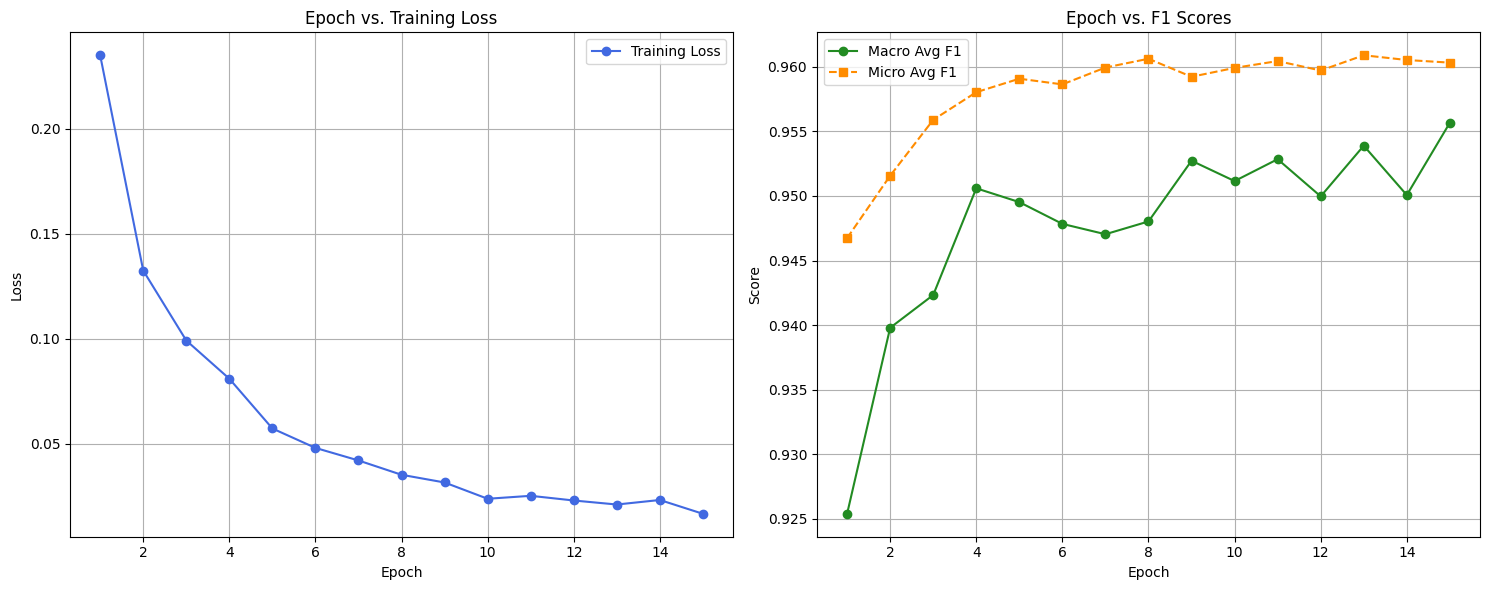

In [16]:
# --- 7. Final Report, Plotting, and Saving ---

print("\n" + "="*50)
print("Final Test Set Performance (from last epoch)")
print("="*50)
# Use the dictionary from the last epoch to print the final report string
final_report_str = classification_report(true_labels, predictions, digits=4)
print(final_report_str)

# --- MODIFICATION 4: Convert the list of logs directly to a DataFrame ---
history_df = pd.DataFrame(history_log)

# Set epoch as the index if you prefer
# history_df = history_df.set_index('epoch')

output_filename = 'DeBERTa_detailed_datapoints.csv'
history_df.to_csv(output_filename, index=False)
print(f"\nDetailed metrics saved to '{output_filename}'")


# Plotting (you can choose which metric to plot, e.g., macro avg F1)
epochs_range = history_df['epoch']

plt.figure(figsize=(15, 6))
plt.subplot(1, 2, 1)
plt.plot(epochs_range, history_df['train_loss'], label='Training Loss', marker='o', color='royalblue')
plt.title('Epoch vs. Training Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.grid(True)
plt.legend()

plt.subplot(1, 2, 2)
# Plotting overall scores
plt.plot(epochs_range, history_df['f1-score_macro_avg'], label='Macro Avg F1', marker='o', color='forestgreen')
plt.plot(epochs_range, history_df['f1-score_micro_avg'], label='Micro Avg F1', marker='s', linestyle='--', color='darkorange')
# You can also plot specific label scores, for example:
# plt.plot(epochs_range, history_df['f1-score_NAME'], label='F1 Score (NAME)', linestyle=':', color='crimson')

plt.title('Epoch vs. F1 Scores')
plt.xlabel('Epoch')
plt.ylabel('Score')
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()


In [17]:
!zip -r file_deberta.zip /kaggle/working/best_cocktail_ner_model


  adding: kaggle/working/best_cocktail_ner_model/ (stored 0%)
  adding: kaggle/working/best_cocktail_ner_model/merges.txt (deflated 53%)
  adding: kaggle/working/best_cocktail_ner_model/tokenizer_config.json (deflated 74%)
  adding: kaggle/working/best_cocktail_ner_model/vocab.json (deflated 59%)
  adding: kaggle/working/best_cocktail_ner_model/config.json (deflated 61%)
  adding: kaggle/working/best_cocktail_ner_model/tokenizer.json

huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)


 (deflated 82%)
  adding: kaggle/working/best_cocktail_ner_model/model.safetensors (deflated 7%)
  adding: kaggle/working/best_cocktail_ner_model/special_tokens_map.json (deflated 83%)
